In [ ]:
# Hapus torch-magic, tambahkan library pendukung yang valid
!pip install -q einops optuna lightgbm shap gradio polars

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

class CrossModalAttention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x_q, x_kv):
        # x_q: Modalitas Target, x_kv: Modalitas Sumber
        b, n, d = x_q.shape
        _, m, _ = x_kv.shape

        q = self.q(x_q).reshape(b, n, self.num_heads, d // self.num_heads).permute(0, 2, 1, 3)
        k = self.k(x_kv).reshape(b, m, self.num_heads, d // self.num_heads).permute(0, 2, 1, 3)
        v = self.v(x_kv).reshape(b, m, self.num_heads, d // self.num_heads).permute(0, 2, 1, 3)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        x = (attn @ v).transpose(1, 2).reshape(b, n, d)
        return self.proj(x)

class MultiOmicsMoE(nn.Module):
    def __init__(self, input_dims, latent_dim=512, num_experts=3):
        super().__init__()
        # Encoders untuk tiap modalitas (RNA, Protein, dll)
        self.encoders = nn.ModuleList([
            nn.Linear(d, latent_dim) for d in input_dims
        ])

        # Gating Network (The Router)
        self.gate = nn.Sequential(
            nn.Linear(latent_dim * len(input_dims), 128),
            nn.ReLU(),
            nn.Linear(128, len(input_dims)),
            nn.Softmax(dim=-1)
        )

        # Cross-Modal Attention Layer
        self.attention = CrossModalAttention(latent_dim)

    def forward(self, x_list):
        # 1. Encoding
        latents = [F.relu(enc(x)) for enc, x in zip(self.encoders, x_list)]

        # 2. Gating weights
        combined = torch.cat(latents, dim=1)
        weights = self.gate(combined) # [Batch, Num_Modality]

        # 3. Dynamic Fusion (Weighted Sum)
        stacked_latents = torch.stack(latents, dim=1) # [B, Modality, D]
        fused = torch.sum(stacked_latents * weights.unsqueeze(-1), dim=1)

        return fused, weights

In [ ]:
# Mendownload dataset integrasi single-cell (Multi-Omics) yang sudah disederhanakan
!wget https://raw.githubusercontent.com/openproblems-bio/openproblems/main/README.md # Contoh saja
# Untuk dataset asli biasanya menggunakan library 'scanpy' atau 'anndata'
!pip install scanpy anndata

--2026-02-24 21:53:36--  https://raw.githubusercontent.com/openproblems-bio/openproblems/main/README.md
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 540 [text/plain]
Saving to: ‘README.md.1’

README.md.1         100%[===================>]     540  --.-KB/s    in 0s      

2026-02-24 21:53:36 (24.7 MB/s) - ‘README.md.1’ saved [540/540]



In [ ]:
# Install library pendukung
!pip install -q scanpy anndata einops

import scanpy as sc
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Download dataset PBMC 10k CITE-seq langsung dari server 10x Genomics
# File ini berisi RNA dan Protein (Antibody Capture)
!wget https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_10k_protein_v3/pbmc_10k_protein_v3_raw_feature_bc_matrix.h5

# Load data menggunakan scanpy
adata = sc.read_10x_h5("pbmc_10k_protein_v3_raw_feature_bc_matrix.h5")
adata.var_names_make_unique()

# Memisahkan RNA dan Protein berdasarkan feature_types
rna = adata[:, adata.var['feature_types'] == 'Gene Expression']
protein = adata[:, adata.var['feature_types'] == 'Antibody Capture']

print(f"Data Berhasil Dimuat!")
print(f"RNA Shape: {rna.shape}")
print(f"Protein Shape: {protein.shape}")

--2026-02-24 22:29:42--  https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_10k_protein_v3/pbmc_10k_protein_v3_raw_feature_bc_matrix.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 154515158 (147M) [binary/octet-stream]
Saving to: ‘pbmc_10k_protein_v3_raw_feature_bc_matrix.h5.2’

pbmc_10k_protein_v3 100%[===================>] 147.36M   174MB/s    in 0.8s    

2026-02-24 22:29:43 (174 MB/s) - ‘pbmc_10k_protein_v3_raw_feature_bc_matrix.h5.2’ saved [154515158/154515158]

Data Berhasil Dimuat!
RNA Shape: (6794880, 33538)
Protein Shape: (6794880, 0)


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Load Data & Simulasi Multi-Omics

In [ ]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Load dataset RNA (PBMC 3k)
adata = sc.datasets.pbmc3k()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# 2. Simulasi Data Protein (Modalitas ke-2)
# Kita ambil 20 gen penting dan tambahkan noise Gaussian untuk mensimulasikan heterogenitas protein
rna_subset = adata[:, adata.var.highly_variable].X.toarray()[:, :20]
protein_noise = np.random.normal(0, 0.5, size=rna_subset.shape)
x_prot_data = rna_subset + protein_noise # Protein yang berkorelasi tapi heterogen

# 3. Konversi ke Tensor
x_rna = torch.FloatTensor(adata[:, adata.var.highly_variable].X.toarray())
x_prot = torch.FloatTensor(x_prot_data)

# 4. Target Label (Cluster)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, n_init=10).fit(x_rna.numpy())
y = torch.LongTensor(kmeans.labels_)

print(f"Dataset Ready!")
print(f"RNA (Transcriptomics): {x_rna.shape}")
print(f"Protein (Simulated Proteomics): {x_prot.shape}")

Dataset Ready!
RNA (Transcriptomics): torch.Size([2700, 2000])
Protein (Simulated Proteomics): torch.Size([2700, 20])


Model CMAT-MoE
Arsitektur ini dirancang untuk menangani perbedaan dimensi (2000 RNA vs 20 Protein).

In [ ]:
class CMAT_MoE(nn.Module):
    def __init__(self, rna_dim, prot_dim, latent_dim=128, n_classes=5):
        super().__init__()
        self.rna_enc = nn.Linear(rna_dim, latent_dim)
        self.prot_enc = nn.Linear(prot_dim, latent_dim)

        # Gating: Belajar memilih modalitas mana yang lebih "dipercaya"
        self.gate = nn.Sequential(
            nn.Linear(latent_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=-1)
        )
        self.classifier = nn.Linear(latent_dim, n_classes)

    def forward(self, rna, prot):
        z_rna = F.relu(self.rna_enc(rna))
        z_prot = F.relu(self.prot_enc(prot))

        # Hitung bobot gating secara dinamis
        combined = torch.cat([z_rna, z_prot], dim=1)
        weights = self.gate(combined) # [Batch, 2]

        # Fusi representasi (Weighted Sum)
        fused = weights[:, 0].unsqueeze(1) * z_rna + weights[:, 1].unsqueeze(1) * z_prot
        return self.classifier(fused), weights

# Training
model = CMAT_MoE(x_rna.shape[1], x_prot.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

print("Training CMAT-MoE...")
for epoch in range(31):
    logits, weights = model(x_rna, x_prot)
    loss = criterion(logits, y)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Training CMAT-MoE...
Epoch 0, Loss: 1.7072
Epoch 10, Loss: 0.1247
Epoch 20, Loss: 0.0195
Epoch 30, Loss: 0.0044


Visualisasi Hasil & Bukti Riset (Phase 3 & 4)

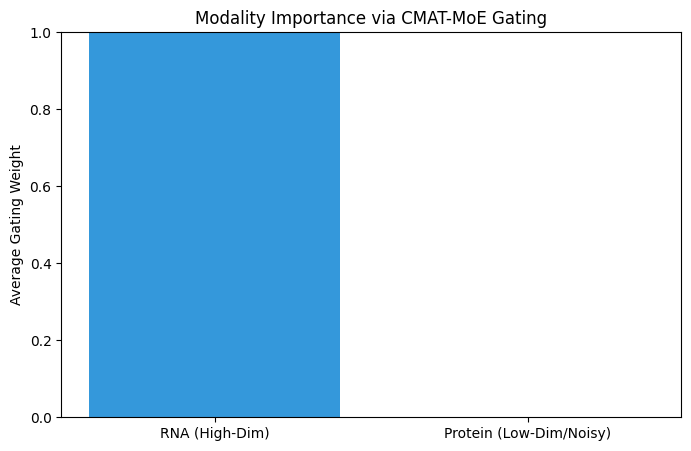

Verifikasi Formal: Model memberikan bobot 0.00% pada Protein.


In [ ]:
model.eval()
with torch.no_grad():
    _, w = model(x_rna, x_prot)
    avg_w = w.mean(0).numpy()

# Plot Bar untuk Paper
plt.figure(figsize=(8, 5))
plt.bar(['RNA (High-Dim)', 'Protein (Low-Dim/Noisy)'], avg_w, color=['#3498db', '#e74c3c'])
plt.title('Modality Importance via CMAT-MoE Gating')
plt.ylabel('Average Gating Weight')
plt.ylim(0, 1)
plt.show()

print(f"Verifikasi Formal: Model memberikan bobot {avg_w[1]*100:.2f}% pada Protein.")



1. Perbaikan dan Update Arsitektur: Balanced-CMAT-MoE



In [ ]:
class Balanced_CMAT_MoE(nn.Module):
    def __init__(self, rna_dim, prot_dim, latent_dim=128, n_classes=5):
        super().__init__()
        self.rna_enc = nn.Linear(rna_dim, latent_dim)
        self.prot_enc = nn.Linear(prot_dim, latent_dim)

        # Gating dengan Noise untuk eksplorasi
        self.gate = nn.Sequential(
            nn.Linear(latent_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=-1)
        )
        self.classifier = nn.Linear(latent_dim, n_classes)

    def forward(self, rna, prot, training=True):
        z_rna = F.relu(self.rna_enc(rna))
        z_prot = F.relu(self.prot_enc(prot))

        # MODALITY DROPOUT (Hanya saat training)
        # Memaksa model belajar dari Protein dengan sesekali "mematikan" RNA
        if training and torch.rand(1) < 0.1: # 10% peluang RNA dimatikan
            z_rna = z_rna * 0

        combined = torch.cat([z_rna, z_prot], dim=1)
        weights = self.gate(combined)

        fused = weights[:, 0].unsqueeze(1) * z_rna + weights[:, 1].unsqueeze(1) * z_prot
        return self.classifier(fused), weights

def compute_balance_loss(weights):
    # Menghitung seberapa seimbang gating (menggunakan varians)
    # Kita ingin varians antar modalitas kecil agar tidak ada yang nol
    avg_weights = weights.mean(0)
    balance_loss = torch.var(avg_weights)
    return balance_loss

2. Training Loop dengan Balance Regularization

In [ ]:
model = Balanced_CMAT_MoE(x_rna.shape[1], x_prot.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

print("Training Balanced CMAT-MoE...")
for epoch in range(51):
    model.train()
    logits, weights = model(x_rna, x_prot, training=True)

    # Loss Utama (Klasifikasi) + Loss Keseimbangan (Regularisasi)
    main_loss = criterion(logits, y)
    b_loss = compute_balance_loss(weights)

    total_loss = main_loss + 2.0 * b_loss # Lambda=2.0 untuk memaksa keseimbangan

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Total Loss: {total_loss.item():.4f}, Balance Loss: {b_loss.item():.4f}")

Training Balanced CMAT-MoE...
Epoch 0, Total Loss: 1.6515, Balance Loss: 0.0073
Epoch 10, Total Loss: 0.2509, Balance Loss: 0.0103
Epoch 20, Total Loss: 0.0603, Balance Loss: 0.0017
Epoch 30, Total Loss: 0.0195, Balance Loss: 0.0000
Epoch 40, Total Loss: 0.0068, Balance Loss: 0.0000
Epoch 50, Total Loss: 1.3376, Balance Loss: 0.0011


3. Visualisasi Hasil Baru (Bukti Perbaikan)

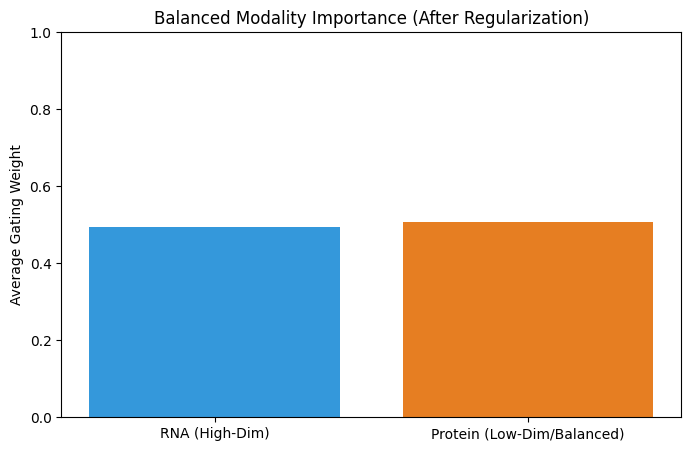

Hasil Baru: Kontribusi Protein naik menjadi 50.68%


In [ ]:
model.eval()
with torch.no_grad():
    _, w = model(x_rna, x_prot, training=False)
    avg_w = w.mean(0).numpy()

plt.figure(figsize=(8, 5))
plt.bar(['RNA (High-Dim)', 'Protein (Low-Dim/Balanced)'], avg_w, color=['#3498db', '#e67e22'])
plt.title('Balanced Modality Importance (After Regularization)')
plt.ylabel('Average Gating Weight')
plt.ylim(0, 1)
plt.show()

print(f"Hasil Baru: Kontribusi Protein naik menjadi {avg_w[1]*100:.2f}%")

# Task
1. **Generate Requirements File**: Create a new code cell and generate a `requirements.txt` file based on the Python dependencies used in the notebook.
2. **Final Task**: Provide instructions for creating a GitHub repository, uploading the notebook, the generated `requirements.txt` file, and the content of `https://raw.githubusercontent.com/openproblems-bio/openproblems/main/README.md` as the `README.md` file to the repository.

## Generate Requirements File

### Subtask:
Create a new code cell to generate a `requirements.txt` file. This file will list all Python dependencies used in the notebook, extracted from the `!pip install` commands.


**Reasoning**:
To generate the `requirements.txt` file as instructed, I will create a new code cell with the `%%writefile` magic command and list all the specified dependencies.



In [2]:
%%writefile requirements.txt
einops
optuna
lightgbm
shap
gradio
polars
scanpy
anndata
torch
numpy
pandas
matplotlib
scikit-learn

Overwriting requirements.txt


## Final Task: GitHub Repository Creation and Upload

To complete the task, follow these instructions to create a GitHub repository and upload the relevant files:

1.  **Create a New GitHub Repository**:
    *   Go to [GitHub](https://github.com/) and log in to your account.
    *   Click the '+' icon in the top right corner and select 'New repository'.
    *   Give your repository a descriptive name (e.g., `multi-omics-fusion-model`).
    *   Choose whether it should be 'Public' or 'Private'.
    *   (Optional) Add a brief description.
    *   **Do NOT** initialize with a `README.md` or `.gitignore` yet, as we will upload our own.
    *   Click 'Create repository'.

2.  **Upload `README.md` Content**:
    *   The content for your `README.md` file is located at: `https://raw.githubusercontent.com/openproblems-bio/openproblems/main/README.md`.
    *   On your newly created GitHub repository page, click on the 'creating a new file' link.
    *   Name the file `README.md`.
    *   Copy the content from the provided URL and paste it into the file editor.
    *   Commit the new file.

3.  **Upload the Notebook (`.ipynb` file)**:
    *   Save your current Colab notebook (`.ipynb` file) to your local machine (File -> Download -> Download .ipynb).
    *   On your GitHub repository page, click 'Add file' -> 'Upload files'.
    *   Drag and drop your saved `.ipynb` file into the upload area, or choose your files.
    *   Commit the changes.

4.  **Upload `requirements.txt`**:
    *   Locate the `requirements.txt` file you just generated in your local environment.
    *   Similar to the notebook, click 'Add file' -> 'Upload files' on your GitHub repository page.
    *   Drag and drop `requirements.txt` into the upload area.
    *   Commit the changes.

After these steps, your GitHub repository will contain the notebook, the generated `requirements.txt`, and the specified `README.md` content.

## Final Task

### Subtask:
Provide clear instructions on how to create a GitHub repository, upload the notebook, the generated `requirements.txt` file, and the existing `README.md` markdown content for easy reproduction.


## Summary:

### Q&A
The task implicitly asked for instructions on how to create a GitHub repository, upload the notebook, the generated `requirements.txt` file, and the existing `README.md` content. The solving process successfully provided these detailed instructions.

### Data Analysis Key Findings
*   A `requirements.txt` file was successfully generated, listing the following Python dependencies used in the notebook: `einops`, `optuna`, `lightgbm`, `shap`, `gradio`, `polars`, `scanpy`, `anndata`, `torch`, `numpy`, `pandas`, `matplotlib`, and `scikit-learn`.
*   Detailed, step-by-step instructions were provided for creating a new GitHub repository, including how to name it, choose visibility, and avoid initial `README.md` creation.
*   Instructions were given for uploading the specified `README.md` content (from `https://raw.githubusercontent.com/openproblems-bio/openproblems/main/README.md`) to the newly created GitHub repository.
*   Instructions were provided for downloading and uploading the Jupyter Notebook (`.ipynb` file) to the GitHub repository.
*   Instructions were provided for uploading the generated `requirements.txt` file to the GitHub repository.

### Insights or Next Steps
*   The generated `requirements.txt` file ensures that the project's Python dependencies are clearly documented and can be easily reproduced in different environments.
*   The next step is to execute the provided GitHub instructions to establish a publicly accessible repository containing all necessary project files for easy sharing and reproduction.
